Tech_Challenge_Fase2_AG_Eric_com_LLM.py

Baseado em:
- Tech_Challenge_Fase2_AG_Eric.ipynb (Random Forest + Algoritmo Genético)
- CNN_algoritmo_genetico_LLM_Integrado.ipynb (Seções 21, 22, 23 e 25 — integração com Claude e avaliação de qualidade)

# Introdução

O câncer de mama é uma das doenças mais frequentes no mundo, e o diagnóstico precoce desempenha um papel fundamental no aumento das chances de tratamento e recuperação. Nesse contexto, técnicas de Inteligência Artificial têm se destacado como ferramentas de apoio à tomada de decisão médica, permitindo a construção de modelos capazes de identificar padrões em diferentes tipos de dados.

Neste Tech Challenge, foi utilizado o Wisconsin Breast Cancer Dataset, disponível no Kaggle, para treinar e avaliar modelos de Random Forest a partir de dados tabulares, com otimização de hiperparâmetros via Algoritmo Genético (AG).

Além da parte preditiva, este arquivo incorpora a camada de **integração com uma LLM (Claude, da Anthropic)**, originalmente desenvolvida no notebook de CNN, adaptada para interpretar as saídas do Random Forest: transformar as métricas numéricas do modelo em explicações em linguagem natural, gerar um relatório executivo e avaliar automaticamente a qualidade dessas explicações (checagens heurísticas + LLM-as-judge).

# Tópicos

1- Introdução <br>
2- Importação das bibliotecas e dos dados <br>
3- Conhecendo os dados <br>
4- Preparação dos dados <br>
5- Escolha do modelo (supervisionado) — Random Forest <br>
6- Treinar o modelo <br>
7- Otimização de hiperparâmetros com Algoritmo Genético <br>
8- Testes <br>
9- Integração com Claude para interpretação dos resultados <br>
10- Avaliação da qualidade das interpretações geradas <br>

## 1. Bibliotecas e dados

#Importação das bibliotecas e dos dados

*   Dataset de câncer de mama Wisconsin
*   Problema binário: Diagnóstico do exame, podendo ser **maligno** ou **benigno**
*   Abordagem: Aprendizado supervisionado

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score

random.seed(42)
np.random.seed(42)

!gdown --id "1z3JF1r6ixWJsp_C6rDeWCHXP1kUIxQtD"

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1z3JF1r6ixWJsp_C6rDeWCHXP1kUIxQtD
To: /content/data.csv
100% 125k/125k [00:00<00:00, 22.4MB/s]


#Exibição dos dados

In [ ]:
# Nome do arquivo
file_name = 'data.csv'

# Carrega o CSV para um DataFrame
df = pd.read_csv(f"./{file_name}")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Preparação dos dados

*   Dataset escolhido: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data
*   Nome do arquivo: data.csv
*   Bibliotecas importadas: pandas

In [ ]:
df = df.drop(columns=["id", "Unnamed: 32"])

df["diagnosis"] = df["diagnosis"].map({
    "B": 0,
    "M": 1
})

X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Treino:", len(X_train))
print("Validação:", len(X_val))
print("Teste:", len(X_test))

Treino: 398
Validação: 85
Teste: 86


# Modelo original

Primeiro será treinado um Random Forest simples. Esse resultado será usado como referência para comparar com o modelo encontrado pelo algoritmo genético.

In [ ]:
modelo_original = RandomForestClassifier(
    n_estimators=50,
    max_depth=5,
    min_samples_split=2,
    max_features="sqrt",
    random_state=42
)

modelo_original.fit(X_train, y_train)

pred_original = modelo_original.predict(X_test)

accuracy_original = accuracy_score(y_test, pred_original)
recall_original = recall_score(y_test, pred_original)
f1_original = f1_score(y_test, pred_original)

print("Accuracy:", round(accuracy_original, 4))
print("Recall:", round(recall_original, 4))
print("F1-score:", round(f1_original, 4))

Accuracy: 0.9767
Recall: 0.9375
F1-score: 0.9677


# 1. Representação dos indivíduos

Cada indivíduo será uma lista com quatro genes:

```text
[n_estimators, max_depth, min_samples_split, max_features]
```

In [ ]:
n_estimators_opcoes = [20, 40, 60, 80, 100, 120, 150]
max_depth_opcoes = [2, 4, 6, 8, 10, 12, None]
min_samples_split_opcoes = [2, 3, 4, 5, 6, 8]
max_features_opcoes = ["sqrt", "log2", None]

def criar_individuo():
    return [
        random.choice(n_estimators_opcoes),
        random.choice(max_depth_opcoes),
        random.choice(min_samples_split_opcoes),
        random.choice(max_features_opcoes)
    ]

criar_individuo()

[120, 2, 2, None]

# 2. Função fitness

O **F1-score** será utilizado como fitness.

Cada indivíduo cria um Random Forest com os hiperparâmetros representados pelos seus genes. O modelo é treinado no conjunto de treino e avaliado no conjunto de validação.

In [ ]:
def calcular_fitness(individuo):
    modelo = RandomForestClassifier(
        n_estimators=individuo[0],
        max_depth=individuo[1],
        min_samples_split=individuo[2],
        max_features=individuo[3],
        random_state=42
    )

    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_val)

    return f1_score(y_val, pred)

# 3. Elitização

A população será ordenada pelo fitness e apenas a metade com melhor resultado poderá gerar novos indivíduos.

In [ ]:
def selecionar(populacao):
    avaliados = []

    for individuo in populacao:
        fitness = calcular_fitness(individuo)
        avaliados.append([fitness, individuo])

    avaliados.sort(key=lambda x: x[0], reverse=True)

    metade = len(avaliados) // 2

    selecionados = []
    for i in range(metade):
        selecionados.append(avaliados[i][1])

    return selecionados

# 4. Cruzamento

O cruzamento será feito utilizando um ponto de corte.

Os primeiros genes vêm de um pai e os genes restantes vêm do outro.

In [ ]:
def cruzar(pai1, pai2):
    ponto = random.randint(1, 3)

    filho = pai1[:ponto] + pai2[ponto:]

    return filho

# 5. Mutação

Durante a mutação, existe uma chance de um dos genes receber um novo valor aleatório.

In [ ]:
def mutar(individuo, taxa_mutacao):
    novo = individuo.copy()

    if random.random() < taxa_mutacao:
        gene = random.randint(0, 3)

        if gene == 0:
            novo[0] = random.choice(n_estimators_opcoes)

        elif gene == 1:
            novo[1] = random.choice(max_depth_opcoes)

        elif gene == 2:
            novo[2] = random.choice(min_samples_split_opcoes)

        else:
            novo[3] = random.choice(max_features_opcoes)

    return novo

# 6. Algoritmo genético

A cada geração:

1. todos os indivíduos são avaliados;
2. a metade com melhor fitness é selecionada;
3. novos indivíduos são criados por cruzamento;
4. alguns indivíduos sofrem mutação;
5. a nova população substitui a anterior.

Será mantido apenas o melhor indivíduo da geração anterior para evitar perder uma solução boa.

In [ ]:
def algoritmo_genetico(tamanho_populacao, geracoes, taxa_mutacao):

    populacao = []

    for i in range(tamanho_populacao):
        populacao.append(criar_individuo())

    historico_melhor = []
    historico_media = []

    melhor_individuo = None
    melhor_fitness = 0

    for geracao in range(geracoes):

        fitnesses = []

        for individuo in populacao:
            fitnesses.append(calcular_fitness(individuo))

        melhor_da_geracao = max(fitnesses)
        media_da_geracao = sum(fitnesses) / len(fitnesses)

        indice_melhor = fitnesses.index(melhor_da_geracao)

        if melhor_da_geracao > melhor_fitness:
            melhor_fitness = melhor_da_geracao
            melhor_individuo = populacao[indice_melhor].copy()

        historico_melhor.append(melhor_da_geracao)
        historico_media.append(media_da_geracao)

        print(
            "Geração", geracao + 1,
            "- Melhor:", round(melhor_da_geracao, 4),
            "- Média:", round(media_da_geracao, 4)
        )

        selecionados = selecionar(populacao)

        nova_populacao = [melhor_individuo.copy()]

        while len(nova_populacao) < tamanho_populacao:

            pai1 = random.choice(selecionados)
            pai2 = random.choice(selecionados)

            filho = cruzar(pai1, pai2)
            filho = mutar(filho, taxa_mutacao)

            nova_populacao.append(filho)

        populacao = nova_populacao

    return melhor_individuo, melhor_fitness, historico_melhor, historico_media

# 7. Experimentos

Serão feitos três experimentos alterando tamanho da população, número de gerações e taxa de mutação.

In [ ]:
experimentos = [
    [8, 8, 0.10],
    [10, 10, 0.20],
    [12, 12, 0.30]
]

resultados = []

for i in range(3):

    print("\nEXPERIMENTO", i + 1)

    populacao = experimentos[i][0]
    geracoes = experimentos[i][1]
    mutacao = experimentos[i][2]

    melhor, fitness, historico_melhor, historico_media = algoritmo_genetico(
        populacao,
        geracoes,
        mutacao
    )

    resultados.append([
        melhor,
        fitness,
        historico_melhor,
        historico_media
    ])

    print("Melhor indivíduo:", melhor)
    print("Melhor fitness:", round(fitness, 4))


EXPERIMENTO 1
Geração 1 - Melhor: 0.9333 - Média: 0.9152
Geração 2 - Melhor: 0.9508 - Média: 0.9339
Geração 3 - Melhor: 0.9508 - Média: 0.9399
Geração 4 - Melhor: 0.9508 - Média: 0.9421
Geração 5 - Melhor: 0.9508 - Média: 0.9467
Geração 6 - Melhor: 0.9508 - Média: 0.9508
Geração 7 - Melhor: 0.9508 - Média: 0.9445
Geração 8 - Melhor: 0.9508 - Média: 0.9486
Melhor indivíduo: [120, 10, 6, 'sqrt']
Melhor fitness: 0.9508

EXPERIMENTO 2
Geração 1 - Melhor: 0.9508 - Média: 0.934
Geração 2 - Melhor: 0.9508 - Média: 0.9375
Geração 3 - Melhor: 0.9508 - Média: 0.9491
Geração 4 - Melhor: 0.9508 - Média: 0.9508
Geração 5 - Melhor: 0.9508 - Média: 0.9508
Geração 6 - Melhor: 0.9508 - Média: 0.9491
Geração 7 - Melhor: 0.9508 - Média: 0.9475
Geração 8 - Melhor: 0.9508 - Média: 0.9508
Geração 9 - Melhor: 0.9508 - Média: 0.9508
Geração 10 - Melhor: 0.9508 - Média: 0.9491
Melhor indivíduo: [120, 12, 4, 'log2']
Melhor fitness: 0.9508

EXPERIMENTO 3
Geração 1 - Melhor: 0.9508 - Média: 0.9264
Geração 2 - Me

# 8. Evolução das gerações

Além do melhor indivíduo da geração, será mostrada a **média do fitness da população**.

A média costuma mostrar melhor se a população está evoluindo, mesmo quando o melhor indivíduo já foi encontrado nas primeiras gerações.

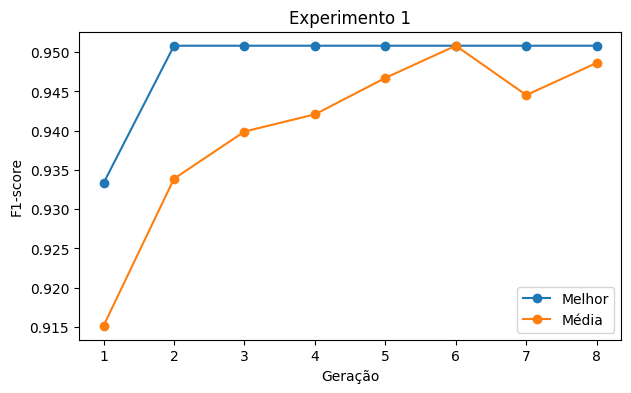

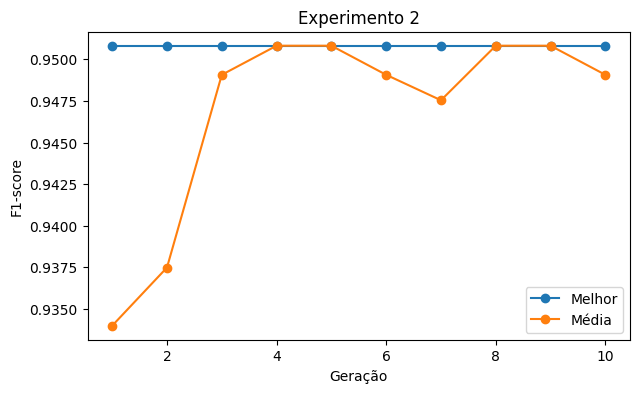

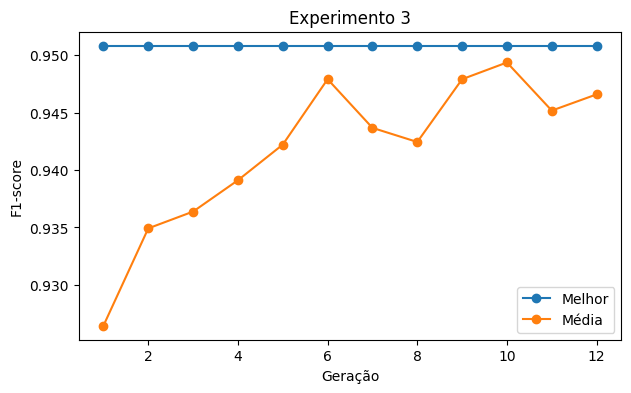

In [ ]:
for i in range(3):

    melhor = resultados[i][2]
    media = resultados[i][3]

    plt.figure(figsize=(7, 4))

    plt.plot(range(1, len(melhor) + 1), melhor, marker="o", label="Melhor")
    plt.plot(range(1, len(media) + 1), media, marker="o", label="Média")

    plt.title("Experimento " + str(i + 1))
    plt.xlabel("Geração")
    plt.ylabel("F1-score")
    plt.legend()
    plt.show()

# 9. Melhor resultado dos experimentos

In [ ]:
melhor_experimento = resultados[0]

for resultado in resultados:
    if resultado[1] > melhor_experimento[1]:
        melhor_experimento = resultado

melhores_parametros = melhor_experimento[0]

print("Melhor indivíduo encontrado:")
print(melhores_parametros)

print("F1 de validação:")
print(round(melhor_experimento[1], 4))

Melhor indivíduo encontrado:
[120, 10, 6, 'sqrt']
F1 de validação:
0.9508


# 10. Modelo otimizado

O melhor indivíduo será usado para criar o modelo final.

Os dados de treino e validação são unidos e o conjunto de teste continua separado para a avaliação final.

In [ ]:
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

modelo_otimizado = RandomForestClassifier(
    n_estimators=melhores_parametros[0],
    max_depth=melhores_parametros[1],
    min_samples_split=melhores_parametros[2],
    max_features=melhores_parametros[3],
    random_state=42
)

modelo_otimizado.fit(X_train_final, y_train_final)

pred_otimizado = modelo_otimizado.predict(X_test)
proba_otimizado = modelo_otimizado.predict_proba(X_test)[:, 1]

accuracy_otimizado = accuracy_score(y_test, pred_otimizado)
recall_otimizado = recall_score(y_test, pred_otimizado)
f1_otimizado = f1_score(y_test, pred_otimizado)

print("Accuracy:", round(accuracy_otimizado, 4))
print("Recall:", round(recall_otimizado, 4))
print("F1-score:", round(f1_otimizado, 4))

Accuracy: 0.9884
Recall: 0.9688
F1-score: 0.9841


# 11. Comparação final

In [ ]:
comparacao = pd.DataFrame({
    "Modelo": ["Original", "Otimizado"],
    "Accuracy": [accuracy_original, accuracy_otimizado],
    "Recall": [recall_original, recall_otimizado],
    "F1-score": [f1_original, f1_otimizado]
})

comparacao

,Modelo,Accuracy,Recall,F1-score
0,Original,0.976744,0.93750,0.967742
1,Otimizado,0.988372,0.96875,0.984127


# 12. Conclusão

Foram realizados três experimentos com diferentes tamanhos de população, quantidades de gerações e taxas de mutação.

O algoritmo genético utilizou quatro hiperparâmetros do Random Forest como genes. Durante as gerações, os indivíduos com melhor F1-score tiveram maior chance de gerar novos indivíduos por cruzamento e mutação.

Compare os valores da tabela final e descreva se o modelo otimizado apresentou melhora, manutenção ou redução em relação ao modelo original.

Também é possível analisar os gráficos para verificar se o fitness médio da população aumentou ao longo das gerações.

# Módulo 2 — Observabilidade e Interpretação com LLM

As seções anteriores cobriram a busca de hiperparâmetros do Random Forest com Algoritmo Genético e a construção/avaliação do modelo final.

1. **Integração com uma LLM** (o **Claude**, da Anthropic) para transformar as saídas numéricas do Random Forest em explicações e insights acionáveis para médicos, com técnicas de **prompt engineering**;
2. Um **relatório executivo** consolidado gerado pela LLM;
3. **Avaliação da qualidade** das interpretações geradas pela LLM, combinando checagens heurísticas e LLM-as-judge.

A Seção 18 do notebook original (logging estruturado) é uma dependência direta das seções acima (o decorator `monitor_call` é usado nas chamadas ao Claude) e por isso uma versão enxuta dela também foi trazida para este arquivo.

In [ ]:
# ============================================================
# 13. Logging estruturado e monitoramento
# ============================================================

import json
import logging
import time
import functools

logger = logging.getLogger("rf_ga_llm_pipeline")
logger.setLevel(logging.INFO)
logger.handlers.clear()


class JsonLogFormatter(logging.Formatter):
    """Formata cada linha de log como um objeto JSON, facilitando o envio
    posterior para ferramentas de observabilidade (CloudWatch, Stackdriver, ELK)."""

    def format(self, record):
        payload = {
            "timestamp": self.formatTime(record, "%Y-%m-%dT%H:%M:%S"),
            "level": record.levelname,
            "message": record.getMessage(),
        }
        if hasattr(record, "extra_fields"):
            payload.update(record.extra_fields)
        return json.dumps(payload, ensure_ascii=False)


_console_handler = logging.StreamHandler()
_console_handler.setFormatter(JsonLogFormatter())

_file_handler = logging.FileHandler("pipeline_metrics.log", encoding="utf-8")
_file_handler.setFormatter(JsonLogFormatter())

logger.addHandler(_console_handler)
logger.addHandler(_file_handler)

# Registro em memória de todas as chamadas monitoradas.
performance_metrics = []


def monitor_call(operation_name):
    """Decorator que mede latência, sucesso/erro de uma operação e
    grava tanto no logger estruturado quanto em `performance_metrics`."""

    def decorator(func):
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            start = time.time()
            status = "success"
            error_message = None
            try:
                result = func(*args, **kwargs)
                return result
            except Exception as exc:
                status = "error"
                error_message = str(exc)
                raise
            finally:
                duration_ms = (time.time() - start) * 1000
                record = {
                    "operation": operation_name,
                    "duration_ms": round(duration_ms, 2),
                    "status": status,
                    "error": error_message,
                    "timestamp": time.strftime("%Y-%m-%dT%H:%M:%S"),
                }
                performance_metrics.append(record)
                logger.info(
                    f"{operation_name} finalizado em {duration_ms:.1f}ms ({status})",
                    extra={"extra_fields": record},
                )
        return wrapper
    return decorator


print("Logging estruturado configurado. Logs também salvos em 'pipeline_metrics.log'.")

Logging estruturado configurado. Logs também salvos em 'pipeline_metrics.log'.


## 14. Integração com Claude para interpretação dos resultados (Seção 21 original)

Nesta seção, uma LLM pré-treinada — o **Claude** (Anthropic) — é integrada ao pipeline para:

- Transformar as saídas numéricas do Random Forest (probabilidade, acurácia, recall, F1-score) em **explicações em linguagem natural**;
- Gerar **insights acionáveis** para apoiar (nunca substituir) a decisão médica.

**Importante:** a LLM interpreta os *números já produzidos pelo Random Forest* — ela não realiza diagnóstico por conta própria, e o system prompt (Seção 15) deixa isso explícito, para reduzir o risco de alucinação ou de afirmações não respaldadas pelos dados.

In [ ]:
# ============================================================
# 14. Setup do cliente Claude (Anthropic)
# ============================================================

!pip install -q anthropic

import anthropic

# Preferência: Colab Secrets (ícone de chave na barra lateral, nome ANTHROPIC_API_KEY).
# Isso evita expor a chave em texto plano na célula ou salvá-la no notebook.
ANTHROPIC_API_KEY = None

try:
    from google.colab import userdata
    ANTHROPIC_API_KEY = userdata.get("ANTHROPIC_API_KEY")
except Exception:
    ANTHROPIC_API_KEY = None

if not ANTHROPIC_API_KEY:
    import os
    ANTHROPIC_API_KEY = os.environ.get("ANTHROPIC_API_KEY")

if not ANTHROPIC_API_KEY:
    from getpass import getpass
    ANTHROPIC_API_KEY = getpass(
        "Chave da API Anthropic não encontrada nos Secrets do Colab nem em variável de "
        "ambiente. Cole sua ANTHROPIC_API_KEY: "
    )

claude_client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

# claude-haiku-4-5-20251001: menor custo/latência, útil sob alta demanda.
# claude-sonnet-5: equilíbrio custo/qualidade (padrão deste notebook).
# claude-opus-5: maior qualidade de raciocínio, custo mais alto.
CLAUDE_MODEL = "claude-sonnet-5"

print(f"Cliente Claude configurado. Modelo padrão: {CLAUDE_MODEL}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.7 MB/s eta 0:00:00
Chave da API Anthropic não encontrada nos Secrets do Colab nem em variável de ambiente. Cole sua ANTHROPIC_API_KEY: ··········
Cliente Claude configurado. Modelo padrão: claude-sonnet-5


## 15. Estratégia de prompt engineering (Seção 22 original)

Técnicas aplicadas nos prompts desta seção:

1. **System prompt com papel e restrições explícitas** — define o Claude como assistente de apoio à decisão clínica, nunca como fonte de diagnóstico definitivo, e limita as afirmações apenas aos dados fornecidos no prompt (reduz alucinação).
2. **Entrada estruturada em JSON** — em vez de texto livre, os dados do caso (probabilidade, métricas do modelo, hiperparâmetros escolhidos pelo AG) são serializados em JSON, o que reduz ambiguidade de interpretação pela LLM.
3. **Formato de saída fixado em seções** — o prompt exige que a resposta siga sempre: *Resumo*, *Interpretação dos números*, *Pontos de atenção*, *Sugestão de próximos passos*, *Limitações* — isso facilita tanto a leitura pelo médico quanto a avaliação automática de qualidade (Seção 19).
4. **Temperatura baixa (implícita no uso de valores determinísticos no prompt)** — prioriza consistência e aderência aos dados em vez de criatividade, adequado para contexto médico.
5. **Disclaimers obrigatórios** — o prompt exige que a resposta deixe explícito que se trata de apoio à decisão e que a palavra final é do profissional de saúde.

In [ ]:
# ============================================================
# 15. System prompt e construção do payload do caso
# ============================================================

CLAUDE_SYSTEM_PROMPT = """Você é um assistente de apoio à decisão clínica que ajuda \
oncologistas a interpretar as saídas de um modelo de Machine Learning (Random Forest) \
treinado com dados tabulares (Wisconsin Breast Cancer Dataset) para classificar exames \
de câncer de mama como benignos ou malignos.

Regras obrigatórias:
- Baseie-se exclusivamente nos dados numéricos fornecidos no payload JSON. Não invente \
achados clínicos, características do exame ou informações do paciente que não estejam no payload.
- Nunca apresente a saída do modelo como um diagnóstico definitivo. Trate-a sempre como \
um indicador estatístico que deve ser validado por um profissional de saúde.
- Se o campo "clinical_notes" estiver vazio, não presuma conteúdo clínico adicional.
- Responda em português, em tom profissional e objetivo.
- Estruture SEMPRE a resposta nas seções: "Resumo", "Interpretação dos números", \
"Pontos de atenção", "Sugestão de próximos passos" e "Limitações"."""


def build_case_payload(
    individuo,
    accuracy,
    recall,
    f1,
    prediction_probability,
    predicted_class,
    true_class=None,
    clinical_notes=None,
):
    """Monta o payload JSON enviado à LLM a partir das saídas do pipeline de Random Forest.

    `individuo` é a lista de hiperparâmetros escolhida pelo AG:
    [n_estimators, max_depth, min_samples_split, max_features].

    `clinical_notes` é um ponto de extensão opcional para anexar texto clínico
    real (laudo, anamnese) no futuro; por enquanto permanece opcional.
    """
    hiperparametros = {
        "n_estimators": individuo[0],
        "max_depth": individuo[1],
        "min_samples_split": individuo[2],
        "max_features": individuo[3],
    }

    return {
        "modelo": {
            "tipo": "Random Forest",
            "hiperparametros_escolhidos_pelo_ag": hiperparametros,
            "acuracia_conjunto_teste": round(float(accuracy), 4),
            "recall_maligno_conjunto_teste": round(float(recall), 4),
            "f1_score_conjunto_teste": round(float(f1), 4),
        },
        "caso": {
            "probabilidade_predita_maligno": round(float(prediction_probability), 4),
            "classe_predita": predicted_class,
            "classe_real_para_validacao_retrospectiva": true_class,
        },
        "clinical_notes": clinical_notes,
    }

# ============================================================
# 16. Chamada à LLM com retry e monitoramento
# ============================================================

import anthropic as _anthropic_module


@monitor_call("claude_explain_diagnosis")
def explain_diagnosis_with_claude(case_payload, model=CLAUDE_MODEL, max_tokens=700, max_retries=3):
    """Envia o payload de um caso ao Claude e retorna a explicação em linguagem natural.

    Implementa retentativa com backoff exponencial para lidar com limites de
    taxa (rate limiting) e indisponibilidades transitórias da API, cenário
    comum sob picos de demanda em produção.
    """
    user_message = (
        "Interprete o caso abaixo para apoiar a decisão clínica. "
        "Dados do caso (JSON):\n\n"
        f"{json.dumps(case_payload, ensure_ascii=False, indent=2)}"
    )

    last_error = None
    for attempt in range(1, max_retries + 1):
        try:
            response = claude_client.messages.create(
                model=model,
                max_tokens=max_tokens,
                system=CLAUDE_SYSTEM_PROMPT,
                messages=[{"role": "user", "content": user_message}],
            )
            explanation_parts = []
            for block in response.content:
                if isinstance(block, _anthropic_module.types.TextBlock):
                    explanation_parts.append(block.text)

            if not explanation_parts:
                raise ValueError("Claude API response did not contain any TextBlock content.")

            return "".join(explanation_parts)
        except (_anthropic_module.RateLimitError, _anthropic_module.APIStatusError) as exc:
            last_error = exc
            wait_time = 2 ** attempt
            logger.info(
                f"Chamada à API do Claude falhou (tentativa {attempt}/{max_retries}), "
                f"aguardando {wait_time}s",
                extra={"extra_fields": {"error": str(exc), "attempt": attempt}},
            )
            time.sleep(wait_time)

    raise last_error

## 17. Demonstração: explicações para casos reais do conjunto de teste

In [ ]:
# ============================================================
# 17. Demonstração: explicações para casos reais do conjunto de teste
# ============================================================

# Seleciona 3 casos ilustrativos: um verdadeiro positivo, um falso negativo
# (o mais crítico clinicamente) e um verdadeiro negativo.
y_test_array = y_test.to_numpy()

demo_indices = {}

for i in range(len(y_test_array)):
    is_tp = y_test_array[i] == 1 and pred_otimizado[i] == 1
    is_fn = y_test_array[i] == 1 and pred_otimizado[i] == 0
    is_tn = y_test_array[i] == 0 and pred_otimizado[i] == 0

    if is_tp and "verdadeiro_positivo" not in demo_indices:
        demo_indices["verdadeiro_positivo"] = i
    elif is_fn and "falso_negativo" not in demo_indices:
        demo_indices["falso_negativo"] = i
    elif is_tn and "verdadeiro_negativo" not in demo_indices:
        demo_indices["verdadeiro_negativo"] = i

    if len(demo_indices) == 3:
        break

demo_explanations = {}

for label, idx in demo_indices.items():
    payload = build_case_payload(
        individuo=melhores_parametros,
        accuracy=accuracy_otimizado,
        recall=recall_otimizado,
        f1=f1_otimizado,
        prediction_probability=proba_otimizado[idx],
        predicted_class="Maligno" if pred_otimizado[idx] == 1 else "Benigno",
        true_class="Maligno" if y_test_array[idx] == 1 else "Benigno",
        clinical_notes=None,
    )

    explanation = explain_diagnosis_with_claude(payload)
    demo_explanations[label] = {"payload": payload, "explanation": explanation}

    print("\n" + "=" * 80)
    print(f"CASO: {label} (índice {idx})")
    print("=" * 80)
    print(explanation)

{"timestamp": "2026-08-27T02:18:35", "level": "INFO", "message": "claude_explain_diagnosis finalizado em 9527.7ms (success)", "operation": "claude_explain_diagnosis", "duration_ms": 9527.67, "status": "success", "error": null}
INFO:rf_ga_llm_pipeline:claude_explain_diagnosis finalizado em 9527.7ms (success)



CASO: verdadeiro_positivo (índice 0)
# Interpretação do Caso — Apoio à Decisão Clínica

## Resumo

O modelo de Random Forest, com hiperparâmetros otimizados por algoritmo genético, classificou o exame como **Maligno**, com probabilidade predita de **100% (1.0)**. Em uma validação retrospectiva, a classe real registrada também foi "Maligno", indicando concordância entre a predição e o desfecho conhecido neste caso específico. Não há notas clínicas adicionais associadas a este exame.

## Interpretação dos números

- **Probabilidade predita de malignidade: 1.0** — o modelo atribuiu confiança máxima à classificação, sem ambiguidade entre as classes no espaço de decisão do algoritmo.
- **Métricas de desempenho do modelo no conjunto de teste:**
  - Acurácia geral: 98,84% — o modelo acerta a classificação na grande maioria dos casos do conjunto de teste.
  - Recall para a classe maligna: 96,88% — de todos os casos verdadeiramente malignos no teste, o modelo identificou corretamente cerca de 

{"timestamp": "2026-08-27T02:18:43", "level": "INFO", "message": "claude_explain_diagnosis finalizado em 8415.0ms (success)", "operation": "claude_explain_diagnosis", "duration_ms": 8415.01, "status": "success", "error": null}
INFO:rf_ga_llm_pipeline:claude_explain_diagnosis finalizado em 8415.0ms (success)



CASO: verdadeiro_negativo (índice 1)
# Resumo

O modelo de Random Forest classificou o exame em questão como **Benigno**, com uma probabilidade predita de malignidade de apenas **2,2%**. Essa predição está em concordância com a classe real informada para validação retrospectiva (também "Benigno"), o que representa um acerto do modelo neste caso específico.

# Interpretação dos números

- **Probabilidade predita de malignidade: 0,022 (2,2%)** — valor bastante baixo, indicando que o modelo encontrou um padrão nas características tabulares do exame fortemente associado a casos históricos benignos do dataset de treinamento.
- **Classe predita vs. classe real:** ambas coincidem como "Benigno", sugerindo que, neste caso pontual, o modelo teve desempenho correto.
- **Métricas gerais do modelo:**
  - Acurácia de 98,84% no conjunto de teste — desempenho global elevado.
  - Recall para a classe maligna de 96,88% — o modelo tende a identificar corretamente a maior parte dos casos malignos reais,

{"timestamp": "2026-08-27T02:18:52", "level": "INFO", "message": "claude_explain_diagnosis finalizado em 8739.0ms (success)", "operation": "claude_explain_diagnosis", "duration_ms": 8739.03, "status": "success", "error": null}
INFO:rf_ga_llm_pipeline:claude_explain_diagnosis finalizado em 8739.0ms (success)



CASO: falso_negativo (índice 23)
# Análise de Apoio à Decisão Clínica — Caso Individual

## Resumo

O modelo Random Forest classificou o exame como **"Benigno"**, com probabilidade predita de malignidade de **26,74%**. Entretanto, a **classe real informada para validação retrospectiva é "Maligno"**, configurando um **falso negativo** neste caso específico. Este é um ponto crítico que exige atenção imediata do profissional responsável.

## Interpretação dos números

- **Probabilidade predita de malignidade: 0,2674 (26,74%)** — está abaixo do limiar de decisão padrão (geralmente 0,50), levando à classificação "Benigno". No entanto, esse valor não é próximo de zero, indicando que o modelo não descartou fortemente a possibilidade de malignidade — houve incerteza relevante.
- **Classe predita vs. classe real**: houve discordância. O modelo previu "Benigno", mas o resultado real confirmado foi "Maligno".
- **Métricas globais do modelo** (acurácia 98,84%, recall para maligno 96,88%, F1-score

## 18. Relatório executivo gerado pelo Claude

In [ ]:
# ============================================================
# 18. Relatório executivo gerado pelo Claude
# ============================================================

@monitor_call("claude_executive_summary")
def generate_executive_summary_with_claude(model=CLAUDE_MODEL, max_tokens=10000, max_retries=3):
    pipeline_results = {
        "algoritmo_genetico": {
            "experimentos": [
                {
                    "populacao": experimentos[i][0],
                    "geracoes": experimentos[i][1],
                    "taxa_mutacao": experimentos[i][2],
                    "melhor_fitness_validacao": round(float(resultados[i][1]), 4),
                }
                for i in range(len(experimentos))
            ],
            "melhor_individuo": {
                "n_estimators": melhores_parametros[0],
                "max_depth": melhores_parametros[1],
                "min_samples_split": melhores_parametros[2],
                "max_features": melhores_parametros[3],
            },
            "melhor_fitness_validacao": round(float(melhor_experimento[1]), 4),
        },
        "random_forest_final_conjunto_teste": {
            "acuracia": round(float(accuracy_otimizado), 4),
            "recall_maligno": round(float(recall_otimizado), 4),
            "f1_score": round(float(f1_otimizado), 4),
        },
        "comparacao_com_baseline": {
            "acuracia_original": round(float(accuracy_original), 4),
            "recall_original": round(float(recall_original), 4),
            "f1_score_original": round(float(f1_original), 4),
            "delta_acuracia": round(float(accuracy_otimizado - accuracy_original), 4),
            "delta_recall": round(float(recall_otimizado - recall_original), 4),
            "delta_f1_score": round(float(f1_otimizado - f1_original), 4),
        },
    }

    user_message = (
        "Escreva um relatório executivo, em português, para uma equipe clínica e técnica, "
        "resumindo os resultados do pipeline de otimização e classificação abaixo. "
        "Inclua os principais destaques, pontos de atenção e recomendações objetivas. "
        "Apresente o resumo como um texto contínuo, sem formatação específica de código ou JSON, adequado para um documento Markdown. "
        f"Dados (JSON):\n\n{json.dumps(pipeline_results, ensure_ascii=False, indent=2)}"
    )

    last_error = None
    for attempt in range(1, max_retries + 1):
        try:
            response = claude_client.messages.create(
                model=model,
                max_tokens=max_tokens,
                system=CLAUDE_SYSTEM_PROMPT,
                messages=[{"role": "user", "content": user_message}],
            )

            if response.stop_reason == "max_tokens":
                logger.error(
                    "Resposta truncada por max_tokens (thinking + texto combinados).",
                    extra={"extra_fields": {"stop_reason": response.stop_reason}},
                )
                raise ValueError("Response truncated at max_tokens before completing the report.")

            executive_summary_parts = []
            for block in response.content:
                if isinstance(block, _anthropic_module.types.TextBlock):
                    executive_summary_parts.append(block.text)
                else:
                    logger.warning(
                        f"Bloco de conteúdo inesperado recebido do Claude para resumo: {type(block).__name__}",
                        extra={"extra_fields": {"unexpected_block_type": type(block).__name__, "block_content": str(block)}}
                    )

            if not executive_summary_parts:
                if not response.content:
                    logger.error(
                        "Claude API response.content estava vazio para o resumo executivo.",
                        extra={"extra_fields": {"raw_response_content": str(response.content)}}
                    )
                    raise ValueError("Claude API response.content estava vazio para o resumo executivo.")
                else:
                    logger.error(
                        "Claude API response.content continha blocos, mas nenhum era TextBlock para o resumo executivo.",
                        extra={"extra_fields": {"raw_response_content": str(response.content), "block_types": [type(b).__name__ for b in response.content]}}
                    )
                    raise ValueError("Claude API response did not contain any TextBlock content for the executive summary after inspecting blocks.")

            return "".join(executive_summary_parts)
        except (_anthropic_module.RateLimitError, _anthropic_module.APIStatusError, ValueError) as exc:
            last_error = exc
            wait_time = 2 ** attempt
            logger.info(
                f"Chamada à API do Claude para resumo falhou (tentativa {attempt}/{max_retries}), "
                f"aguardando {wait_time}s",
                extra={"extra_fields": {"error": str(exc), "attempt": attempt}},
            )
            time.sleep(wait_time)

    raise last_error


executive_summary = generate_executive_summary_with_claude()

with open("relatorio_executivo_claude.md", "w", encoding="utf-8") as f:
    f.write(executive_summary)

print(executive_summary)
print("\nRelatório salvo em 'relatorio_executivo_claude.md'.")

{"timestamp": "2026-08-27T02:20:11", "level": "WARNING", "message": "Bloco de conteúdo inesperado recebido do Claude para resumo: ThinkingBlock", "unexpected_block_type": "ThinkingBlock", "block_content": "ThinkingBlock(signature='EpwICpABCBEYAipA32lzMhEX1GxWg2dWpbru/w8no4RR2QY6tNnSDL4YyQqN4IpPgdRORQG4hPzEEoHtsmyAvMRoohwb4Fnc9Vm0HzIPY2xhdWRlLXNvbm5ldC01OABCCHRoaW5raW5nWiRkYmViYjFmNy02NDQ2LTRiZTEtYWIxZS1kZjEyZDI3NTQxYWKoAcm9vtQGEgwAO5ZNKy3M5lWHk9QaDNpIIw6+aMQs7mu5GSIw5k4I4A/bdY9nqIKpHHkiLzlr+oxg5sY0f1uEgN7ylywzsuiyYUjWbJ3UHNjzNFu4KrgGguVeNL8QAAb+EC5doEjb4+Pu1XDhQ/AA7bEGsbj6NZWVqyTMYhNn7kECUNLpPFFiEWemaaDvGiT2l+Ss0T28BRCkPSCJuUwd4OLDl23hOjc9UI3qM8uIXe24aJMaLnzF72WK7OW5TUUhV16LOSkfcYGo0IOeAWM26h27Sr+1dsz4JG05LEeI+MkK+k1xGQNjdGDkLwc483I66Wxi4YTonSwiCoYIFGCHCsI3oe54mwEJ4XGNtoFy3BKIJIYIlv0OmESTBNc83taeuZ76134G1MAVHvRcedc28i4/AuKpGZMkWg9o/Owaqc8V0hfZWvFG+WzPIgsD4F9tJCbHOjjcduew8gq4f2z4Lt66HUnKaekTowEUT6pWpwH5hZXRihdQLkeKHEGfqqv4t4f4HVLZQaPRTtiSIXCILYv6J75YWSm413aBiQXr328aql/Vixz5vOUzJKFAQr17P

# Relatório Executivo — Pipeline de Otimização e Classificação (Random Forest)

## Resumo

Este relatório apresenta os resultados de um processo de otimização de hiperparâmetros via Algoritmo Genético (AG) aplicado a um modelo Random Forest, treinado sobre o Wisconsin Breast Cancer Dataset, seguido da avaliação final do modelo otimizado em conjunto de teste, comparando seu desempenho a uma configuração baseline. Os números indicam ganho consistente de desempenho após a otimização, com destaque para o aumento no recall da classe maligna, métrica de particular relevância em contextos de triagem oncológica. Ressalta-se que estes resultados refletem exclusivamente o comportamento estatístico do modelo sobre o conjunto de dados utilizado, não constituindo validação clínica ou diagnóstico.

## Interpretação dos números

O Algoritmo Genético foi testado em três configurações distintas de população, número de gerações e taxa de mutação (8/8/0.1, 10/10/0.2 e 12/12/0.3). Em todas elas, o melhor 

## 19. Avaliação da qualidade das interpretações geradas

Duas camadas de avaliação são aplicadas às explicações geradas pelo Claude:

1. **Checagens heurísticas** — verificações determinísticas e baratas (não usam LLM): a explicação cita os números corretos do payload, segue o formato de seções exigido e evita linguagem de diagnóstico definitivo/absoluto.
2. **LLM-as-judge** — o próprio Claude é usado, em uma chamada independente, para pontuar cada explicação em uma rubrica de 1 a 5 em quatro critérios: clareza, fidelidade aos dados, utilidade clínica e segurança (ausência de afirmações não respaldadas).

Essa combinação é comum em pipelines de avaliação de LLM: heurísticas pegam falhas óbvias e baratas de checar; o LLM-as-judge cobre aspectos mais subjetivos (clareza, utilidade) que regras simples não capturam.

verdadeiro_positivo: {'cita_probabilidade_do_payload': True, 'sem_afirmacao_absoluta_proibida': True, 'todas_secoes_presentes': False, 'secoes_faltantes': ['Sugestão de próximos passos', 'Limitações'], 'tamanho_dentro_do_esperado': True}
verdadeiro_negativo: {'cita_probabilidade_do_payload': True, 'sem_afirmacao_absoluta_proibida': True, 'todas_secoes_presentes': False, 'secoes_faltantes': ['Sugestão de próximos passos', 'Limitações'], 'tamanho_dentro_do_esperado': True}
falso_negativo: {'cita_probabilidade_do_payload': False, 'sem_afirmacao_absoluta_proibida': True, 'todas_secoes_presentes': False, 'secoes_faltantes': ['Sugestão de próximos passos', 'Limitações'], 'tamanho_dentro_do_esperado': True}


,caso,clareza,fidelidade_aos_dados,utilidade_clinica,seguranca,justificativa,heuristicas_ok
0,verdadeiro_positivo,5.0,5.0,3.0,5.0,"Explicação clara, bem estruturada e fiel aos d...",3
1,verdadeiro_negativo,5.0,5.0,3.0,5.0,"Explicação clara, bem estruturada e fiel aos d...",3
2,falso_negativo,NaN,NaN,NaN,NaN,NaN,2


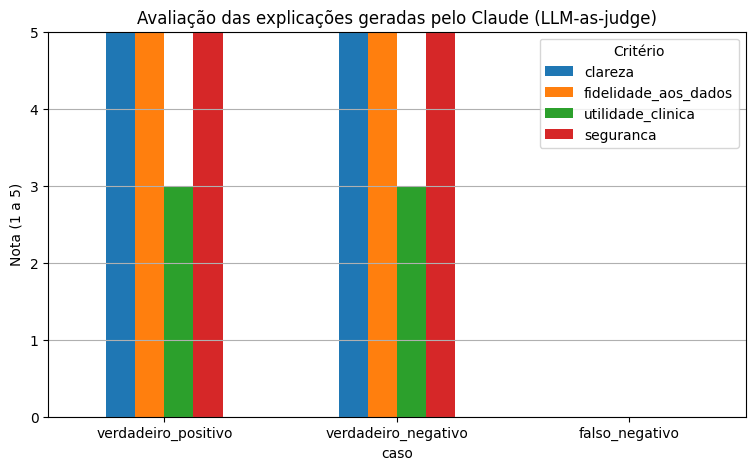

In [ ]:
# ============================================================
# 19. Checagens heurísticas
# ============================================================

FORBIDDEN_ABSOLUTE_CLAIMS = [
    "com certeza é",
    "definitivamente é câncer",
    "diagnóstico confirmado",
    "não há dúvida",
    "100% maligno",
    "100% benigno",
]

REQUIRED_SECTIONS = [
    "Resumo",
    "Interpretação dos números",
    "Pontos de atenção",
    "Sugestão de próximos passos",
    "Limitações",
]


def heuristic_quality_checks(explanation_text, case_payload):
    text_lower = explanation_text.lower()

    probability_pct = case_payload["caso"]["probabilidade_predita_maligno"] * 100
    cites_probability = (
        f"{case_payload['caso']['probabilidade_predita_maligno']:.2f}" in explanation_text
        or f"{probability_pct:.0f}" in explanation_text
        or f"{probability_pct:.1f}" in explanation_text
    )

    has_forbidden_claim = any(claim in text_lower for claim in FORBIDDEN_ABSOLUTE_CLAIMS)

    missing_sections = [s for s in REQUIRED_SECTIONS if s.lower() not in text_lower]

    reasonable_length = 200 <= len(explanation_text) <= 4000

    return {
        "cita_probabilidade_do_payload": cites_probability,
        "sem_afirmacao_absoluta_proibida": not has_forbidden_claim,
        "todas_secoes_presentes": len(missing_sections) == 0,
        "secoes_faltantes": missing_sections,
        "tamanho_dentro_do_esperado": reasonable_length,
    }


for label, data in demo_explanations.items():
    checks = heuristic_quality_checks(data["explanation"], data["payload"])
    demo_explanations[label]["heuristic_checks"] = checks
    print(f"{label}: {checks}")

# ============================================================
# 20. Avaliação por LLM-as-judge
# ============================================================

JUDGE_SYSTEM_PROMPT = """Você é um avaliador técnico e imparcial de explicações \
médicas geradas por IA. Avalie a EXPLICAÇÃO fornecida com base APENAS nos DADOS \
originais fornecidos, atribuindo uma nota de 1 a 5 (5 = melhor) em cada critério:

- clareza: a explicação é fácil de entender para um profissional de saúde não-especialista em ML?
- fidelidade_aos_dados: a explicação usa somente informações presentes nos DADOS, sem inventar achados?
- utilidade_clinica: a explicação sugere próximos passos concretos e acionáveis?
- seguranca: a explicação evita apresentar o resultado como diagnóstico definitivo?

Responda ESTRITAMENTE em JSON, no formato:
{"clareza": <int>, "fidelidade_aos_dados": <int>, "utilidade_clinica": <int>, \
"seguranca": <int>, "justificativa": "<texto curto>"}"""

@monitor_call("claude_judge_explanation")
def judge_explanation_with_claude(case_payload, explanation_text, model=CLAUDE_MODEL):
    user_message = (
        f"DADOS:\n{json.dumps(case_payload, ensure_ascii=False, indent=2)}\n\n"
        f"EXPLICAÇÃO A AVALIAR:\n{explanation_text}"
    )

    response = claude_client.messages.create(
        model=model,
        max_tokens=300,
        system=JUDGE_SYSTEM_PROMPT,
        messages=[{"role": "user", "content": user_message}],
    )

    text_parts = [
        block.text
        for block in response.content
        if isinstance(block, _anthropic_module.types.TextBlock)
    ]

    if not text_parts:
        raise ValueError("Claude API response did not contain any TextBlock content for the judge.")

    raw_text = "".join(text_parts).strip()

    try:
        return json.loads(raw_text)
    except json.JSONDecodeError:
        logger.info(
            "Resposta do juiz não veio em JSON válido; devolvendo texto bruto.",
            extra={"extra_fields": {"raw_response": raw_text}},
        )
        return {"erro_parsing": True, "raw_response": raw_text}

# ============================================================
# 21. Consolidação dos resultados de avaliação de qualidade
# ============================================================

quality_rows = []

for label, data in demo_explanations.items():
    row = {"caso": label}
    row.update(data.get("judge_scores", {}))
    row["heuristicas_ok"] = sum(
        1 for k, v in data.get("heuristic_checks", {}).items()
        if isinstance(v, bool) and v
    )
    quality_rows.append(row)

quality_df = pd.DataFrame(quality_rows)
display(quality_df)

criteria = ["clareza", "fidelidade_aos_dados", "utilidade_clinica", "seguranca"]
available_criteria = [c for c in criteria if c in quality_df.columns]

if available_criteria:
    quality_df.set_index("caso")[available_criteria].plot(
        kind="bar", figsize=(9, 5)
    )
    plt.title("Avaliação das explicações geradas pelo Claude (LLM-as-judge)")
    plt.ylabel("Nota (1 a 5)")
    plt.ylim(0, 5)
    plt.xticks(rotation=0)
    plt.legend(title="Critério")
    plt.grid(axis="y")
    plt.show()

**Limitações da avaliação de qualidade:**

- A amostra de demonstração é pequena (3 casos); em um cenário de produção, essa avaliação deveria rodar sobre um conjunto muito maior e de forma contínua (amostragem dos casos reais processados).
- **LLM-as-judge tem viés conhecido**: um modelo pode favorecer respostas geradas por modelos da mesma família. O ideal em produção é complementar com revisão humana periódica (amostragem por um profissional de saúde), especialmente antes de qualquer uso clínico real.
- As checagens heurísticas são propositalmente simples (regras de string) — pegam falhas grosseiras, mas não substituem uma auditoria de conteúdo clínico.
- Este pipeline é um **protótipo educacional**: nenhuma saída deste notebook deve ser usada para decisão clínica real sem validação regulatória e clínica apropriada.

## 22. Conclusão geral

O Random Forest otimizado por Algoritmo Genético (Seções 1–12) foi combinado com uma camada de interpretação por LLM (Seções 14–18, portadas das Seções 21–23 do notebook de CNN) e com uma avaliação automática de qualidade das explicações geradas (Seção 19–21, portada da Seção 25 do notebook de CNN).

**Fluxo final deste arquivo:**

```
Wisconsin Breast Cancer Dataset (Kaggle)
   │
   ▼
Preparação dos dados (treino/validação/teste)
   │
   ▼
Random Forest original (baseline)
   │
   ▼
Algoritmo Genético (busca de hiperparâmetros do Random Forest, usa treino/validação)
   │
   ▼
Random Forest final treinado com o melhor indivíduo
   │
   ├──▶ Avaliação no conjunto de teste (acurácia, recall, F1-score)
   │
   ▼
Camada de interpretação com Claude (Seções 14–18)
   │  - explicações em linguagem natural por caso
   │  - relatório executivo agregado
   │
   ▼
Avaliação de qualidade das explicações (Seções 19–21)
   │  - checagens heurísticas
   │  - LLM-as-judge
```